In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_csv('steam_games_cleaned.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_name         1964 non-null   object 
 1   price             1964 non-null   float64
 2   review_count      1964 non-null   int64  
 3   developer         1964 non-null   object 
 4   publisher         1964 non-null   object 
 5   genres            1951 non-null   object 
 6   release_year      1964 non-null   int64  
 7   release_month     1964 non-null   int64  
 8   review_sentiment  1964 non-null   object 
 9   review_score      1964 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 153.6+ KB


In [7]:
df.describe()

,price,review_count,release_year,release_month,review_score
count,1964.000000,1.964000e+03,1964.000000,1964.000000,1964.000000
mean,1124.301426,2.172748e+04,2021.950611,6.606415,82.809572
std,1128.286731,8.006495e+04,4.034253,3.611464,13.230293
min,0.000000,1.000000e+01,1998.000000,1.000000,17.000000
25%,389.750000,1.187000e+03,2020.000000,3.000000,76.000000
50%,770.000000,4.302000e+03,2023.000000,7.000000,86.000000
75%,1499.000000,1.586375e+04,2025.000000,10.000000,93.000000
max,10874.000000,2.496132e+06,2026.000000,12.000000,100.000000


In [17]:
num_cols = ['price','review_count','release_year','release_month','review_score']
cat_cols = ['developer','publisher','genres','review_sentiment']

In [19]:
len(num_cols)

5

num cols = 5

cat cols = 5

**UNIVARIATE ANALYSIS**

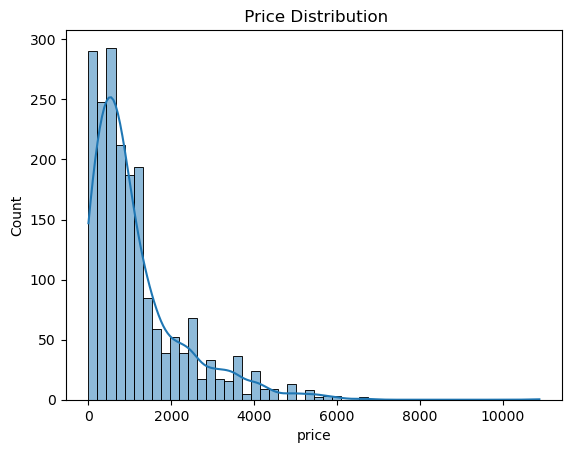

In [48]:
cols = ['price','review_count']
sns.histplot(x=df['price'],bins=50,kde=True)
plt.title(" Price Distribution")
plt.show()

### **Price Distribution Insights**

A large number of games are **free-to-play**, which creates a strong peak near **price = 0** in the distribution.

Most paid games fall within the **₹500 – ₹2000 price range**, indicating that this is the most common pricing range for games on the platform.

Only a small number of games are priced above **₹2000**, suggesting that premium-priced titles are relatively less common.

Overall, the distribution is **right-skewed**, meaning that the majority of games are priced at lower values while a few games have very high prices.


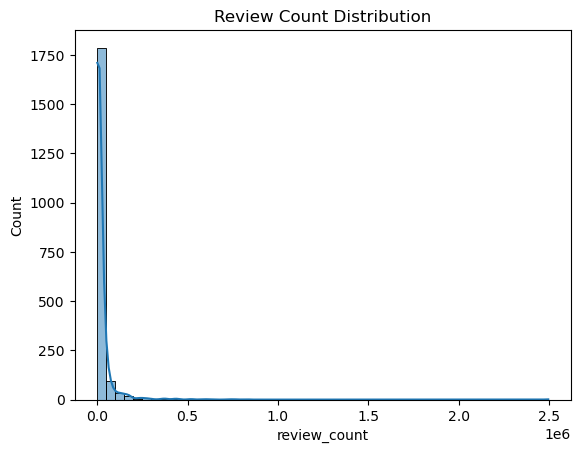

In [58]:
sns.histplot(df['review_count'], bins=50, kde=True)
plt.title("Review Count Distribution")
plt.show()

The review_count distribution is highly right-skewed. Most games receive relatively few reviews, while a small number of games receive extremely large numbers of reviews.

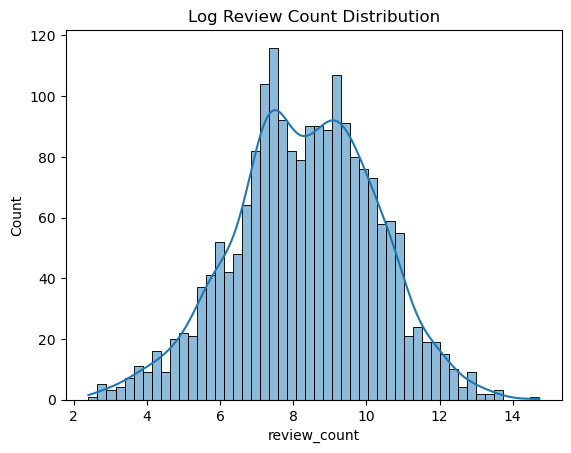

In [46]:
sns.histplot(np.log1p(df['review_count']), bins=50, kde=True)
plt.title("Log Review Count Distribution")
plt.show()

After applying a log transformation (log1p), the distribution becomes approximately normal, reducing skewness and making the variable more suitable for machine learning models.

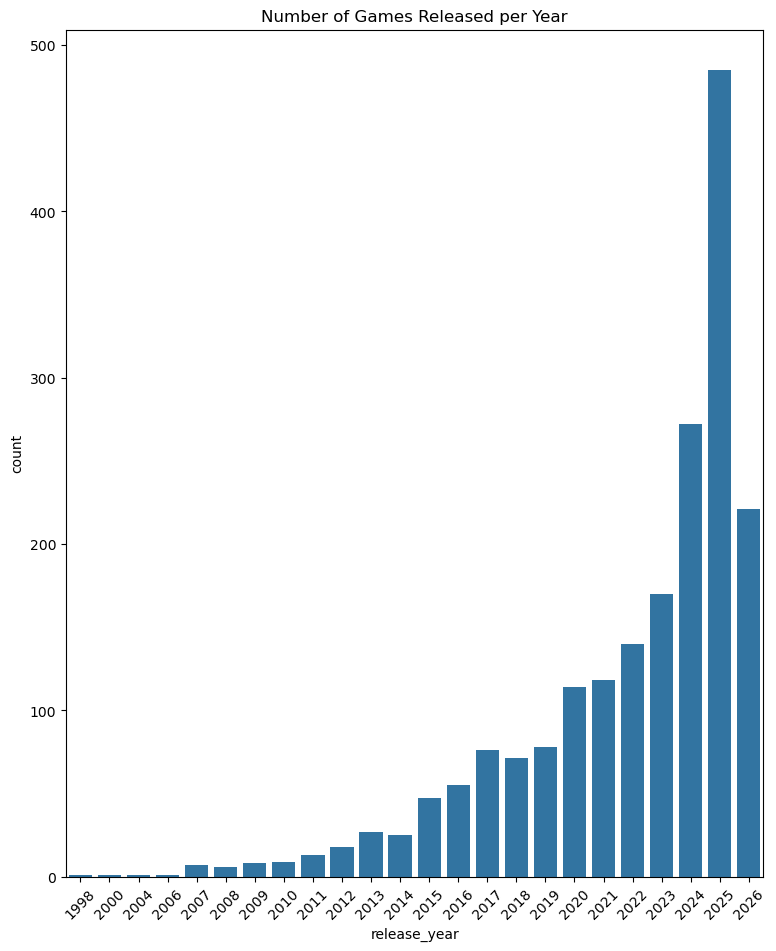

In [78]:
plt.figure(figsize=(9,11))
sns.countplot(x='release_year', data=df, order=sorted(df['release_year'].unique()))

plt.title("Number of Games Released per Year")
plt.xticks(rotation=45)
plt.show()

### **Release Year Distribution**

The number of games released on the platform has gradually increased over the years.

Earlier years show very few releases, while more recent years contain significantly more games.

The highest number of games in this dataset were released around **2024–2025**.

This trend suggests that the game industry has been growing over time, with more titles being released in recent years.

The dataset is also more concentrated on recent releases, likely because modern games are more visible in current Steam listings.


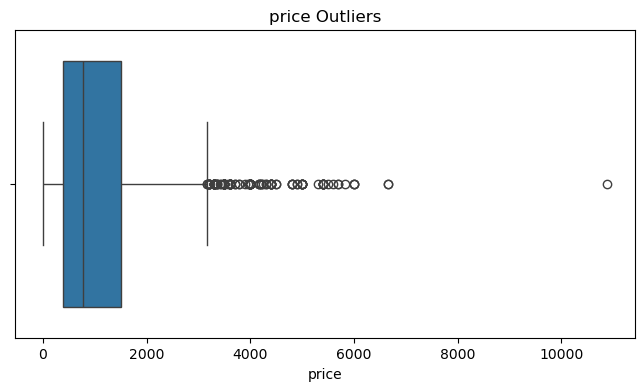

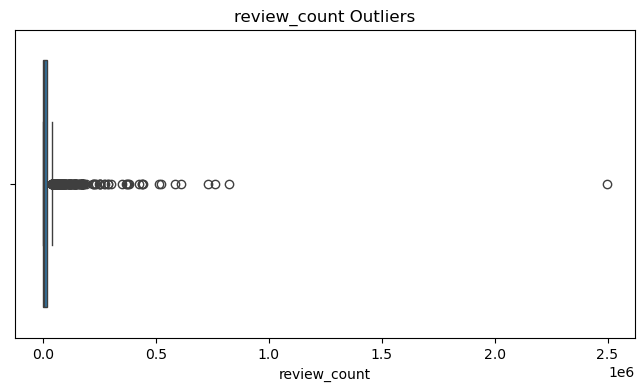

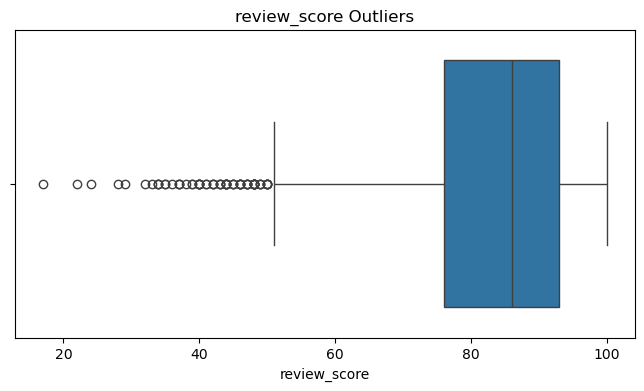

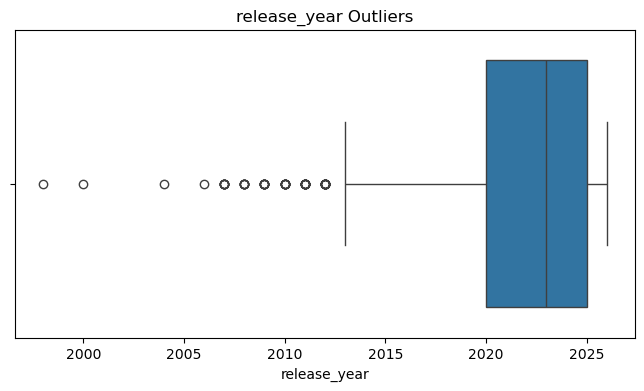

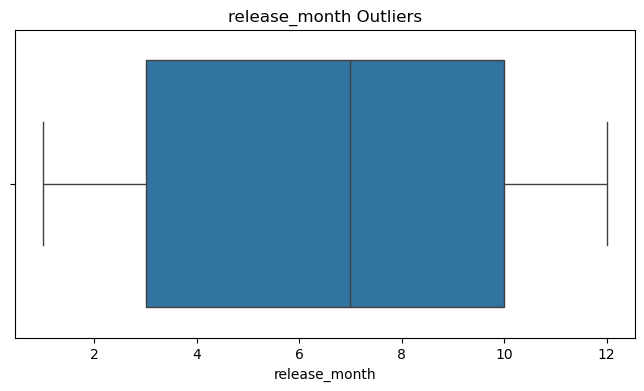

In [86]:
num_cols = ['price','review_count','review_score','release_year','release_month']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Outliers")
    plt.show()

### **Price Outliers**

The boxplot reveals several high price values that appear as outliers. However, these values represent premium or deluxe game editions, which are valid prices in the dataset. Therefore, these observations are not removed, as they represent legitimate market behavior.

### **Review Score Outliers**

The boxplot shows that most games have review scores between 70 and 90, indicating generally positive feedback. A few lower values appear as outliers, representing games with significantly lower user ratings compared to the majority.

### **Release Year Outliers**

The boxplot indicates that most games in the dataset were released between 2018 and 2025. Older games appear as outliers because the dataset is concentrated on more recent releases.

### **Review Count Boxplot**

The boxplot reveals extreme outliers in `review_count`, where a few games have extremely large numbers of reviews. Since popularity data naturally contains such extreme values, a log transformation was applied to stabilize the distribution and reduce the impact of these outliers.


In [14]:
df.columns

Index(['game_name', 'price', 'review_count', 'developer', 'publisher',
       'genres', 'release_year', 'release_month', 'review_sentiment',
       'review_score', 'log_review_count', 'popularity_tier'],
      dtype='object')

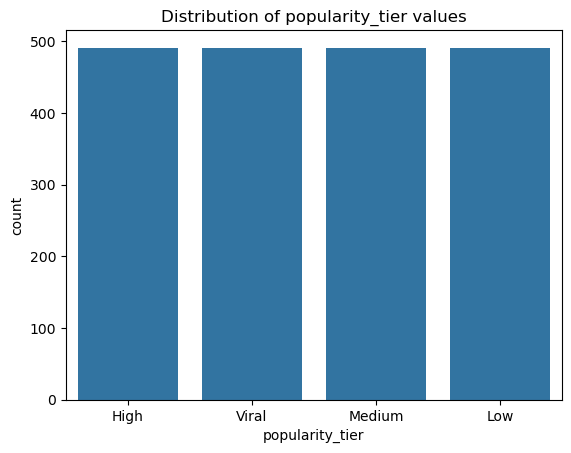

In [11]:
sns.countplot(x='popularity_tier',data = df)
plt.title('Distribution of popularity_tier values')
plt.show()

Since the target variable was transformed into popularity tiers using quartile-based binning, the resulting classes are evenly distributed, which is beneficial for classification modeling.

**BIVARIATE ANALYSIS**

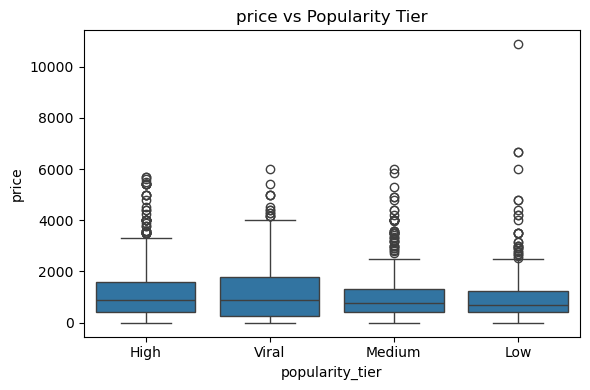

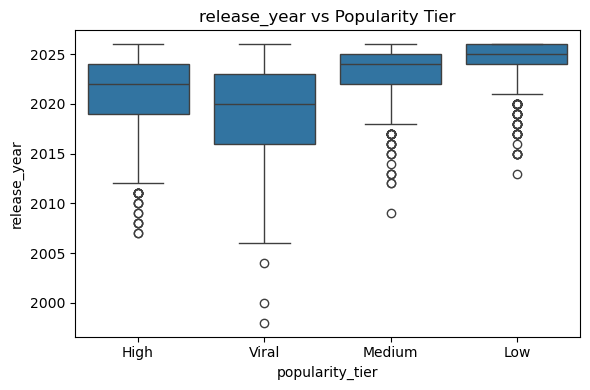

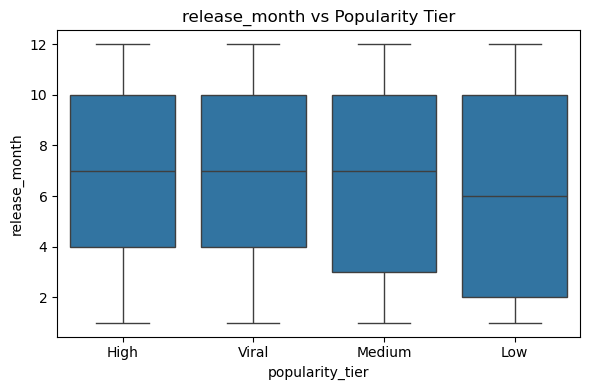

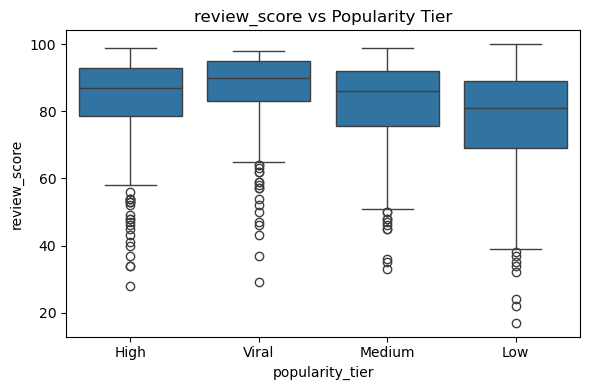

In [16]:
num_cols = ['price','release_year','release_month','review_score']

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x='popularity_tier', y=col, data=df)
    
    plt.title(f"{col} vs Popularity Tier")
    
    plt.tight_layout()
    plt.show()

**Price vs Popularity Tier**
The distribution of prices across popularity tiers shows that games from all price ranges appear in each tier. However, many highly popular or viral games tend to fall within lower to moderate price ranges, suggesting affordability may help games reach a larger audience.

**Release Year vs Popularity Tier**
More recent games appear more frequently in the higher popularity tiers. This likely reflects the growth of the Steam platform and the larger player base in recent years, which increases the potential for games to accumulate reviews.

**Release Month vs Popularity Tier**
The release month distribution is relatively consistent across all popularity tiers, indicating that the month of release does not show a strong relationship with game popularity.

**Review Score vs Popularity Tier**
Higher review scores generally appear in the higher popularity tiers. Games with strong user sentiment are more likely to achieve high or viral popularity, suggesting that positive player feedback plays an important role in a game's success.


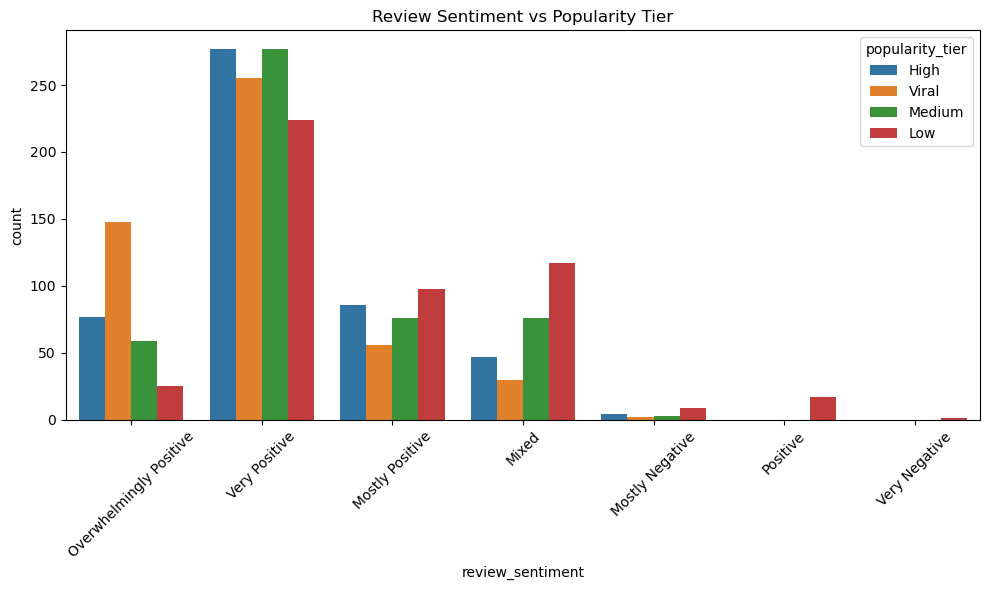

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='review_sentiment',
    hue='popularity_tier',
    data=df
)

plt.xticks(rotation=45)

plt.title("Review Sentiment vs Popularity Tier")

plt.tight_layout()
plt.show()

### Review Sentiment vs Popularity Tier

This plot shows how different review sentiment categories relate to the popularity tiers. Games with **very positive** and **overwhelmingly positive** sentiments appear more frequently in the **high** and **viral** popularity tiers, indicating that strong player satisfaction is often associated with higher popularity.

On the other hand, games with **mixed or negative sentiments** are more commonly found in the **low popularity tier**, suggesting that weaker player feedback may limit a game's reach and engagement.


**MULTIVARIATE ANALYSIS**

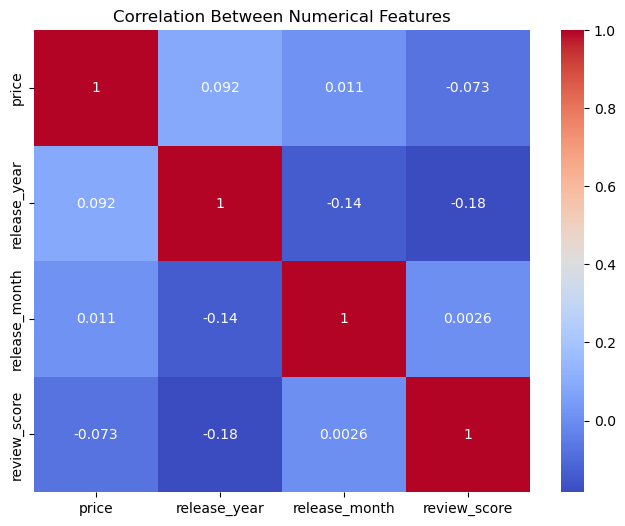

In [23]:
num_cols = ['price','release_year','release_month','review_score']

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numerical Features")
plt.show()

**Correlation Between Numerical Features**
The correlation heatmap shows that the numerical variables (price, release year, release month, and review score) have generally weak correlations with each other. This indicates that these features capture different aspects of the dataset and do not exhibit strong linear relationships.

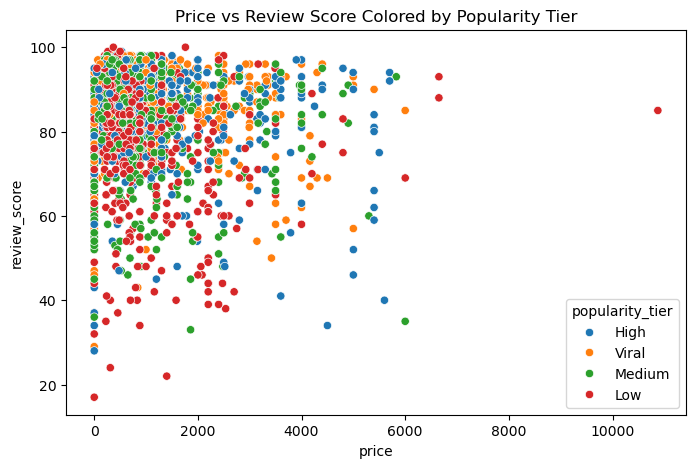

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='price',
    y='review_score',
    hue='popularity_tier'
)

plt.title("Price vs Review Score Colored by Popularity Tier")
plt.show()

**Price vs Review Score Colored by Popularity Tier**
This scatter plot visualizes the relationship between game price and review score while highlighting the popularity tiers. Most games cluster in lower price ranges with relatively high review scores. Higher popularity tiers are more commonly associated with higher review scores, while price does not show a strong pattern with popularity. This suggests that user sentiment (review score) may play a more important role in determining popularity than price alone.
